# CMIP6 Case A — Step 5: Köppen-based climate-zone EDA

**English.** This notebook joins the external 0.1° Köppen–Geiger raster to the MPI-ESM1-2-LR non-ice terrestrial grid and tests whether the 1985–2014 climatological P–ET–R relationships differ among the agreed WW, WD, CW, and CD proxy zones. It remains exploratory: it does not fit a tree or claim that these proxy zones reproduce the four regions in the reference paper.

**中文。** 本 notebook 将新加入的 0.1° Köppen–Geiger 分类匹配到 MPI-ESM1-2-LR 的非冰川陆地网格，检查 1985–2014 年平均 P–ET–R 空间关系在 WW、WD、CW 和 CD 之间是否不同。这仍是 EDA：不建立 tree，也不宣称这个 Köppen proxy 与参考论文中的四个气候区完全等价。

## Step 0 — Configuration and consistent figure style

**English.** Locate the Step 4 climatology table and the Köppen file automatically. All maps use the same Robinson projection and 60°S–90°N display extent as the preceding Case A figures. Cartesian panels use a visible frame around every scatter plot.

**中文。** 自动定位 Step 4 的气候态表和 Köppen 文件。所有地图继续使用 Case A 前面图中的 Robinson 投影和 60°S–90°N 显示范围；每个普通散点子图都保留清晰边框。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import seaborn as sns
from scipy.interpolate import PchipInterpolator
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 220,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#30343B",
    "axes.linewidth": 0.9, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

START_YEAR, END_YEAR = 1985, 2014
MIN_PURITY_FOR_CORE = 0.60
N_AREA_BINS = 12
WRITE_OUTPUTS = True
ZONE_ORDER = ["WW", "WD", "CW", "CD"]
ZONE_LABELS = {
    "WW": "Warm–Wet", "WD": "Warm–Dry",
    "CW": "Cold–Wet", "CD": "Cold–Dry",
}
ZONE_COLORS = {
    "WW": "#078C78", "WD": "#A85F12",
    "CW": "#73C9C2", "CD": "#DFC27D",
}

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#30343B")
        spine.set_linewidth(0.9)
    ax.tick_params(direction="out", length=3.5, width=0.75, color="#30343B")
    ax.grid(True, color="#D3D3D3", linewidth=0.8, alpha=0.80, zorder=0)

CASE_DIR = find_case_dir()
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step5"
KG_PATH = CASE_DIR / "koppen_geiger_0p1.nc"
CLIMATOLOGY_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_spatial_EDA_1985_2014.parquet"
CLIMATOLOGY_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_partition_1985_2014.nc"

for required in [KG_PATH, CLIMATOLOGY_TABLE, CLIMATOLOGY_NETCDF]:
    if not required.exists():
        raise FileNotFoundError(required)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Case directory: {CASE_DIR}")
print(f"Köppen raster: {KG_PATH}")

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Köppen raster: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/koppen_geiger_0p1.nc


## Step 1 — Audit the categorical raster and state the four-zone proxy

**English.** The supplied raster contains Köppen codes 0–30 and a confidence field. Code 0 is ocean/no class. The project mapping already documented in Step 1 is retained exactly:

| Proxy zone | Köppen classes | Codes |
|---|---|---|
| WW | Af, Am, Cwa, Cwb, Cfa, Cfb | 1, 2, 11, 12, 14, 15 |
| WD | Aw, BWh, BSh, Csa, Csb | 3, 4, 6, 8, 9 |
| CW | Cfc, Dfa, Dfb, Dfc, Dfd, ET | 16, 25, 26, 27, 28, 29 |
| CD | BWk, BSk, Csc, Cwc, Dsa–Dsd, Dwa–Dwd | 5, 7, 10, 13, 17–24 |
| Excluded | ocean/no class and EF | 0, 30 |

This is a pragmatic proxy. In particular, ET is assigned to CW because tundra is generally energy-limited; assigning ET to CD is a reasonable sensitivity test if the label is intended to mean low precipitation rather than long-term water limitation. EF is not used because the CMIP analysis domain has already removed model-native permanent land ice with `sftgif`.

**中文。** 输入格点包含 0–30 的 Köppen 编码以及分类信心度，编码0代表海洋或无类别。这里完全沿用 Step 1 已记录的四区映射，不在看到 CMIP 结果后重新调整分类。这只是一个实用 proxy。ET 苔原暂归 CW，因为苔原水循环通常更接近能量限制；若“Dry”仅表示低降水而非长期水分限制，可在后续敏感性检验中把 ET 改归 CD。EF 不进入主分析，因为模型原生 `sftgif` 已排除永久陆地冰。注意：当前 NetCDF 属性没有写明 Köppen 的确切参考时段，在论文中使用前应补充数据版本和时段信息。

In [2]:
KOPPEN_LABELS = {
    1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc",
    20: "Dsd", 21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa",
    26: "Dfb", 27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF",
}
KOPPEN_TO_ZONE = {
    **{code: "WW" for code in [1, 2, 11, 12, 14, 15]},
    **{code: "WD" for code in [3, 4, 6, 8, 9]},
    **{code: "CW" for code in [16, 25, 26, 27, 28, 29]},
    **{code: "CD" for code in [5, 7, 10, 13, 17, 18, 19, 20, 21, 22, 23, 24]},
}
ZONE_TO_CODE = {zone: index for index, zone in enumerate(ZONE_ORDER, start=1)}

kg_ds = xr.open_dataset(KG_PATH)
spatial = xr.open_dataset(CLIMATOLOGY_NETCDF)
clim = pd.read_parquet(CLIMATOLOGY_TABLE).sort_values("grid_id_numeric").reset_index(drop=True)

audit = pd.Series({
    "kg_latitude_cells": kg_ds.sizes["lat"],
    "kg_longitude_cells": kg_ds.sizes["lon"],
    "kg_minimum_code": int(kg_ds["kg_class"].min()),
    "kg_maximum_code": int(kg_ds["kg_class"].max()),
    "kg_minimum_confidence_percent": float(kg_ds["kg_confidence"].min()),
    "kg_maximum_confidence_percent": float(kg_ds["kg_confidence"].max()),
    "cmip_latitude_cells": spatial.sizes["lat"],
    "cmip_longitude_cells": spatial.sizes["lon"],
    "non_ice_analysis_cells": int(spatial["analysis_cell"].sum()),
})
display(audit.to_frame("value"))
assert set(np.unique(kg_ds["kg_class"].values.astype(int))).issubset(set(range(31)))
assert len(clim) == int(spatial["analysis_cell"].sum())

,value
kg_latitude_cells,1800.0
kg_longitude_cells,3600.0
kg_minimum_code,0.0
kg_maximum_code,30.0
kg_minimum_confidence_percent,0.0
kg_maximum_confidence_percent,100.0
cmip_latitude_cells,96.0
cmip_longitude_cells,192.0
non_ice_analysis_cells,4172.0


## Step 2 — Aggregate high-resolution classes to each CMIP grid cell

**English.** A categorical raster must not be bilinearly interpolated. Each 0.1° pixel center is assigned to its nearest MPI grid center; within every MPI cell, high-resolution land pixels are weighted by `cos(latitude)` and summed by class. The dominant four-zone group is selected from those area proxies. `zone_purity` is the dominant group's share of all included grouped pixels, while `kg_grouped_coverage` reports the share not assigned to excluded code 30. The original dominant 30-class code and mean confidence are retained for auditing.

**中文。** Köppen 是离散类别，不能做双线性插值。本步先将每个 0.1° 像元中心分配给最近的 MPI 网格，再用 `cos(latitude)` 近似高分辨率像元面积，在每个 MPI 网格内按类别累加。最终选择面积占比最大的四区类别，同时保留 `zone_purity`（主类占比）、`kg_grouped_coverage`（非 EF 的有效分组占比）、原始30类中的主类和平均信心度。这比只取网格中心的一个 Köppen 值更稳健，也能识别气候边界的混合网格。

In [3]:
cmip_lat = spatial["lat"].values
cmip_lon = spatial["lon"].values
kg_lat = kg_ds["lat"].values
kg_lon = kg_ds["lon"].values

lat_index = np.abs(kg_lat[:, None] - cmip_lat[None, :]).argmin(axis=1)
circular_lon_distance = np.abs(((kg_lon[:, None] - cmip_lon[None, :] + 180) % 360) - 180)
lon_index = circular_lon_distance.argmin(axis=1)

class_area = np.zeros((len(cmip_lat), len(cmip_lon), 31), dtype="float64")
confidence_area_sum = np.zeros((len(cmip_lat), len(cmip_lon)), dtype="float64")
classified_area = np.zeros((len(cmip_lat), len(cmip_lon)), dtype="float64")
kg_classes = kg_ds["kg_class"].values.astype("int16")
kg_confidence = kg_ds["kg_confidence"].values.astype("float32")
latitude_weights = np.cos(np.deg2rad(kg_lat))

for source_i, target_i in enumerate(lat_index):
    row_classes = kg_classes[source_i]
    valid = (row_classes >= 1) & (row_classes <= 30)
    if not valid.any():
        continue
    target_j = lon_index[valid]
    codes = row_classes[valid]
    pixel_weights = np.full(valid.sum(), latitude_weights[source_i])
    np.add.at(class_area[target_i], (target_j, codes), pixel_weights)
    np.add.at(classified_area[target_i], target_j, pixel_weights)
    np.add.at(
        confidence_area_sum[target_i], target_j,
        pixel_weights * kg_confidence[source_i, valid],
    )

group_area = np.zeros((len(cmip_lat), len(cmip_lon), len(ZONE_ORDER)), dtype="float64")
for code, zone_name in KOPPEN_TO_ZONE.items():
    group_area[:, :, ZONE_TO_CODE[zone_name] - 1] += class_area[:, :, code]

grouped_area = group_area.sum(axis=2)
dominant_zone_code = group_area.argmax(axis=2).astype("int8") + 1
dominant_zone_code[grouped_area == 0] = 0
zone_purity = np.divide(
    group_area.max(axis=2), grouped_area,
    out=np.full_like(grouped_area, np.nan), where=grouped_area > 0,
)
kg_grouped_coverage = np.divide(
    grouped_area, classified_area,
    out=np.full_like(grouped_area, np.nan), where=classified_area > 0,
)
kg_mean_confidence = np.divide(
    confidence_area_sum, classified_area,
    out=np.full_like(grouped_area, np.nan), where=classified_area > 0,
)
dominant_koppen_code = class_area[:, :, 1:].argmax(axis=2).astype("int16") + 1
dominant_koppen_code[classified_area == 0] = 0

source_ids = spatial["grid_id"].values.astype(int)
max_grid_id = int(clim["grid_id_numeric"].max())

def grid_to_table_lookup(values, fill_value=np.nan):
    lookup = np.full(max_grid_id + 1, fill_value, dtype=np.asarray(values).dtype)
    valid = source_ids > 0
    lookup[source_ids[valid]] = np.asarray(values)[valid]
    return lookup[clim["grid_id_numeric"].astype(int).to_numpy()]

clim["zone_code"] = grid_to_table_lookup(dominant_zone_code, fill_value=0).astype(int)
code_to_zone = {value: key for key, value in ZONE_TO_CODE.items()}
clim["zone"] = pd.Categorical(
    [code_to_zone.get(code, "Unassigned") for code in clim["zone_code"]],
    categories=ZONE_ORDER, ordered=True,
)
clim["zone_purity"] = grid_to_table_lookup(zone_purity)
clim["kg_grouped_coverage"] = grid_to_table_lookup(kg_grouped_coverage)
clim["kg_mean_confidence"] = grid_to_table_lookup(kg_mean_confidence)
clim["dominant_koppen_code"] = grid_to_table_lookup(dominant_koppen_code, fill_value=0).astype(int)
clim["dominant_koppen_class"] = clim["dominant_koppen_code"].map(KOPPEN_LABELS)
clim["core_zone_cell"] = clim["zone_purity"] >= MIN_PURITY_FOR_CORE

coverage_audit = pd.Series({
    "analysis_cells": len(clim),
    "assigned_zone_cells": int(clim["zone"].notna().sum()),
    "unassigned_zone_cells": int(clim["zone"].isna().sum()),
    "core_cells_purity_ge_0p60": int(clim["core_zone_cell"].sum()),
    "median_zone_purity": float(clim["zone_purity"].median()),
    "10th_percentile_zone_purity": float(clim["zone_purity"].quantile(0.10)),
    "median_KG_confidence_percent": float(clim["kg_mean_confidence"].median()),
})
display(coverage_audit.to_frame("value").round(4))
display(
    clim.groupby("zone", observed=True).agg(
        grid_cells=("grid_id", "size"),
        median_purity=("zone_purity", "median"),
        p10_purity=("zone_purity", lambda x: x.quantile(0.10)),
        median_confidence=("kg_mean_confidence", "median"),
    ).reindex(ZONE_ORDER).round(3)
)
assert coverage_audit["assigned_zone_cells"] == coverage_audit["analysis_cells"]
assert clim["zone_purity"].between(0, 1).all()

,value
analysis_cells,4172.0000
assigned_zone_cells,4172.0000
unassigned_zone_cells,0.0000
core_cells_purity_ge_0p60,3907.0000
median_zone_purity,1.0000
10th_percentile_zone_purity,0.6671
median_KG_confidence_percent,91.0925


,grid_cells,median_purity,p10_purity,median_confidence
zone,,,,
WW,662,0.997,0.613,89.722
WD,1243,1.000,0.721,96.703
CW,1491,1.000,0.748,90.647
CD,776,0.965,0.602,85.747


## Step 3 — Show the climate regions and diagnose classification purity

**English.** The publication-style map uses the original 0.1° Köppen pixels grouped into the four proxy regions, preserving recognizable geographic boundaries. The statistical analysis still uses the dominant area group assigned to each MPI cell in Step 2. Classification purity is moved out of the map and summarized in a separate area-weighted stacked bar chart; this avoids a visually noisy checkerboard while retaining the boundary-mixing diagnostic.

**中文。** 主图改用原始 0.1° Köppen 像元展示四个 proxy 气候区，从而保留可识别的地理边界；统计分析仍使用 Step 2 中按网格内面积主类分配的 MPI 标签，两者不混淆。分类纯度不再画成噪声很强的全球“马赛克”地图，而是单独用面积加权堆叠条形图汇总，既保留边界混合诊断，也不干扰主地图。

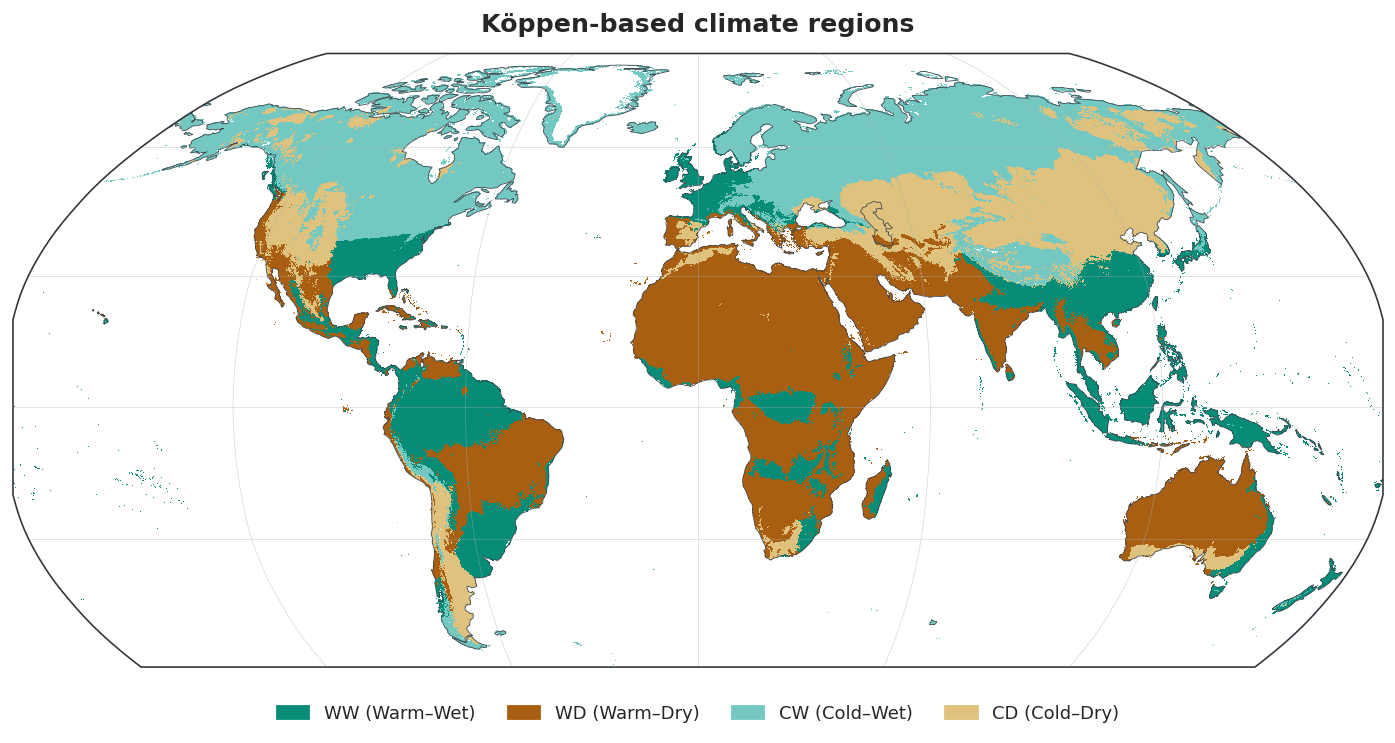

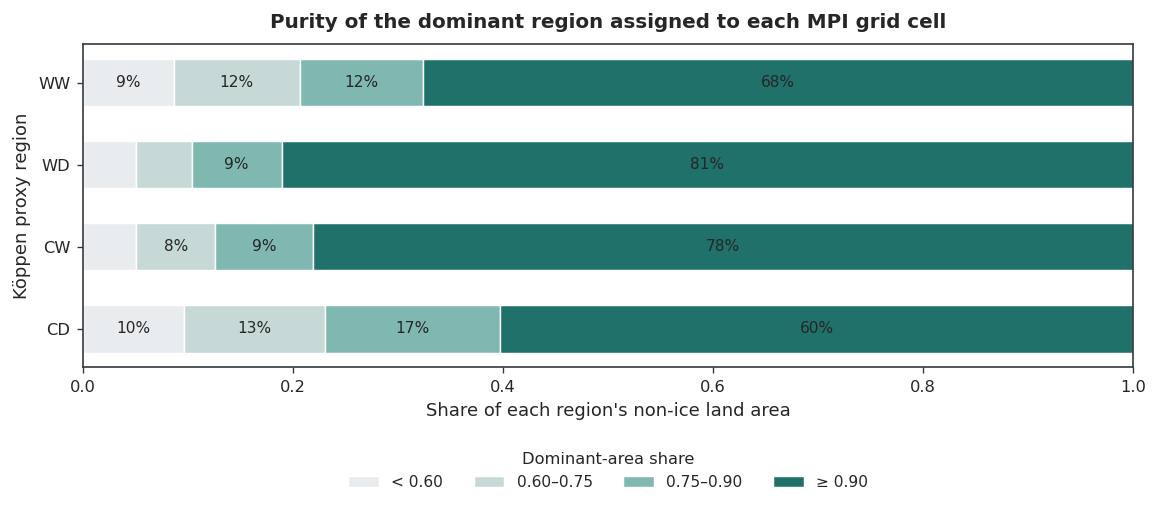

In [4]:
def style_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", color="#3D4650", linewidth=0.45)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=False,
        xlocs=np.arange(-120, 181, 60), ylocs=np.arange(-60, 91, 30),
        color="#AAB1B9", linewidth=0.35, alpha=0.55,
    )
    ax.spines["geo"].set_edgecolor("#30343B")
    ax.spines["geo"].set_linewidth(0.9)

analysis_mask = spatial["analysis_cell"].values.astype(bool)
zone_cmap = ListedColormap([ZONE_COLORS[zone] for zone in ZONE_ORDER])
zone_cmap.set_bad((1, 1, 1, 0))
zone_norm = BoundaryNorm(np.arange(0.5, 5.5, 1), zone_cmap.N)
high_res_zone = np.zeros_like(kg_classes, dtype="float32")
for koppen_code, zone_name in KOPPEN_TO_ZONE.items():
    high_res_zone[kg_classes == koppen_code] = ZONE_TO_CODE[zone_name]
high_res_zone = np.ma.masked_where(high_res_zone == 0, high_res_zone)

projection = ccrs.Robinson()
fig = plt.figure(figsize=(12.6, 5.6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.imshow(
    high_res_zone, origin="upper",
    extent=[kg_lon.min() - 0.05, kg_lon.max() + 0.05, kg_lat.min() - 0.05, kg_lat.max() + 0.05],
    transform=ccrs.PlateCarree(), cmap=zone_cmap, norm=zone_norm,
    interpolation="nearest", regrid_shape=1600, rasterized=True, zorder=1,
)
style_map(ax)
ax.set_title("Köppen-based climate regions", pad=12, fontsize=14, fontweight="semibold")
legend_handles = [
    mpatches.Patch(color=ZONE_COLORS[zone], label=f"{zone} ({ZONE_LABELS[zone]})")
    for zone in ZONE_ORDER
]
ax.legend(
    handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.035),
    ncol=4, frameon=False, fontsize=10, handlelength=1.8, columnspacing=1.8,
)
fig.savefig(FIGURE_DIR / "koppen_zone_map.png", bbox_inches="tight")
plt.show()

purity_edges = np.array([0.0, 0.60, 0.75, 0.90, 1.000001])
purity_labels = ["< 0.60", "0.60–0.75", "0.75–0.90", "≥ 0.90"]
purity_colors = ["#E8ECEF", "#C6D9D6", "#7FB8B1", "#1F7169"]
purity_shares = []
for zone_name in ZONE_ORDER:
    group = clim.loc[clim["zone"] == zone_name]
    weights = group["land_area"].to_numpy(float)
    values = group["zone_purity"].to_numpy(float)
    shares = []
    for lower, upper in zip(purity_edges[:-1], purity_edges[1:]):
        mask = (values >= lower) & (values < upper)
        shares.append(float(weights[mask].sum() / weights.sum()))
    purity_shares.append(shares)
purity_shares = np.asarray(purity_shares)

fig, ax = plt.subplots(figsize=(8.8, 3.8), constrained_layout=True)
left = np.zeros(len(ZONE_ORDER))
for bin_index, (label, color) in enumerate(zip(purity_labels, purity_colors)):
    widths = purity_shares[:, bin_index]
    bars = ax.barh(
        ZONE_ORDER, widths, left=left, height=0.58,
        color=color, edgecolor="white", linewidth=0.8, label=label,
    )
    for row_index, (bar, width) in enumerate(zip(bars, widths)):
        if width >= 0.055:
            ax.text(left[row_index] + width / 2, bar.get_y() + bar.get_height() / 2,
                    f"{100 * width:.0f}%", ha="center", va="center", fontsize=8.5)
    left += widths
ax.set_xlim(0, 1)
ax.set_xlabel("Share of each region's non-ice land area")
ax.set_ylabel("Köppen proxy region")
ax.set_title("Purity of the dominant region assigned to each MPI grid cell", pad=9)
ax.legend(title="Dominant-area share", frameon=False, ncol=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), fontsize=8.5, title_fontsize=9)
style_axes(ax)
ax.grid(False)
ax.invert_yaxis()
fig.savefig(FIGURE_DIR / "koppen_zone_purity_distribution.png", bbox_inches="tight")
plt.show()

## Step 4 — Area-weighted zone summaries and spatial associations

**English.** Report grid count and land-area share separately: grid count is sampling density, whereas land-area share represents physical coverage. For each zone, calculate area-weighted means, medians, interquartile ranges, and weighted spatial rank correlations. These are relationships among 30-year mean grid cells, not annual correlations and not independent replicates because nearby cells are spatially autocorrelated.

**中文。** 网格数和陆地面积占比必须分开报告：前者反映采样密度，后者才反映物理覆盖范围。每个区计算面积加权均值、中位数、四分位范围和加权空间秩相关。这些是30年平均网格之间的空间关系，不是年际相关；由于存在空间自相关，各网格也不是完全独立的重复样本。

In [5]:
def weighted_quantile(values, weights, quantile=0.5):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    order = np.argsort(values[valid])
    sorted_values = values[valid][order]
    sorted_weights = weights[valid][order]
    cumulative = np.cumsum(sorted_weights)
    return float(sorted_values[np.searchsorted(cumulative, quantile * cumulative[-1])])

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[valid], weights=weights[valid]))

def weighted_pearson(x, y, weights):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights) & (weights > 0)
    x, y, weights = x[valid], y[valid], weights[valid]
    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)
    numerator = np.sum(weights * (x - x_mean) * (y - y_mean))
    denominator = np.sqrt(
        np.sum(weights * (x - x_mean) ** 2) * np.sum(weights * (y - y_mean) ** 2)
    )
    return float(numerator / denominator)

def weighted_spearman(x, y, weights):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()
    return weighted_pearson(x_rank, y_rank, weights)

zone_rows = []
total_land_area = clim["land_area"].sum()
for zone_name in ZONE_ORDER:
    group = clim.loc[clim["zone"] == zone_name].copy()
    weights = group["land_area"]
    row = {
        "zone": zone_name,
        "label": ZONE_LABELS[zone_name],
        "grid_cells": len(group),
        "land_area_share": float(weights.sum() / total_land_area),
        "core_cell_share": float(group["core_zone_cell"].mean()),
        "median_zone_purity": weighted_quantile(group["zone_purity"], weights),
        "weighted_rank_r_P_ET": weighted_spearman(group["P"], group["ET"], weights),
        "weighted_rank_r_P_R": weighted_spearman(group["P"], group["R"], weights),
    }
    for variable in ["P", "ET", "R", "ET_fraction_climatology", "R_fraction_climatology"]:
        row[f"{variable}_mean"] = weighted_mean(group[variable], weights)
        row[f"{variable}_q25"] = weighted_quantile(group[variable], weights, 0.25)
        row[f"{variable}_median"] = weighted_quantile(group[variable], weights, 0.50)
        row[f"{variable}_q75"] = weighted_quantile(group[variable], weights, 0.75)
    zone_rows.append(row)

zone_summary = pd.DataFrame(zone_rows).set_index("zone").reindex(ZONE_ORDER)
display_columns = [
    "grid_cells", "land_area_share", "core_cell_share", "median_zone_purity",
    "P_median", "ET_median", "R_median",
    "ET_fraction_climatology_median", "R_fraction_climatology_median",
    "weighted_rank_r_P_ET", "weighted_rank_r_P_R",
]
display(zone_summary[display_columns].round(3))
assert np.isclose(zone_summary["land_area_share"].sum(), 1.0)

,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_fraction_climatology_median,R_fraction_climatology_median,weighted_rank_r_P_ET,weighted_rank_r_P_R
zone,,,,,,,,,,,
WW,662,0.197,0.912,1.000,1356.857,1065.575,180.003,0.853,0.145,0.883,0.820
WD,1243,0.380,0.946,1.000,349.957,328.602,12.034,0.945,0.056,0.996,0.945
CW,1491,0.248,0.958,1.000,712.330,442.480,257.482,0.583,0.418,0.699,0.644
CD,776,0.176,0.901,0.968,439.286,351.563,46.109,0.868,0.133,0.908,0.838


## Step 5 — Draw P–ET and P–R as separate zone panels

**English.** Every CMIP grid cell is drawn as an equal-size point, and the four zones are arranged as a single 1 × 4 row. All panels use identical x and y limits so that their ranges can be compared directly. A smooth area-weighted binned-median curve summarizes the nonlinear relationship without hiding the individual points. No 1:1 dashed line is drawn. The annotation is an area-weighted rank correlation, consistent with a monotonic but potentially nonlinear relationship.

**中文。** 每个 CMIP 网格都用同样大小的散点画出，四个气候区按单行 `1 × 4` 排列。同一关系的四个面板使用完全相同的横纵轴范围，使不同区的取值范围可以直接比较。曲线是按等陆地面积降水分箱得到的加权中位数平滑线，既表现非线性趋势，也不遮住原始点。按你前面的要求，这里不画 1:1 虚线。标注的是面积加权秩相关，适合描述可能非线性但总体单调的关系。

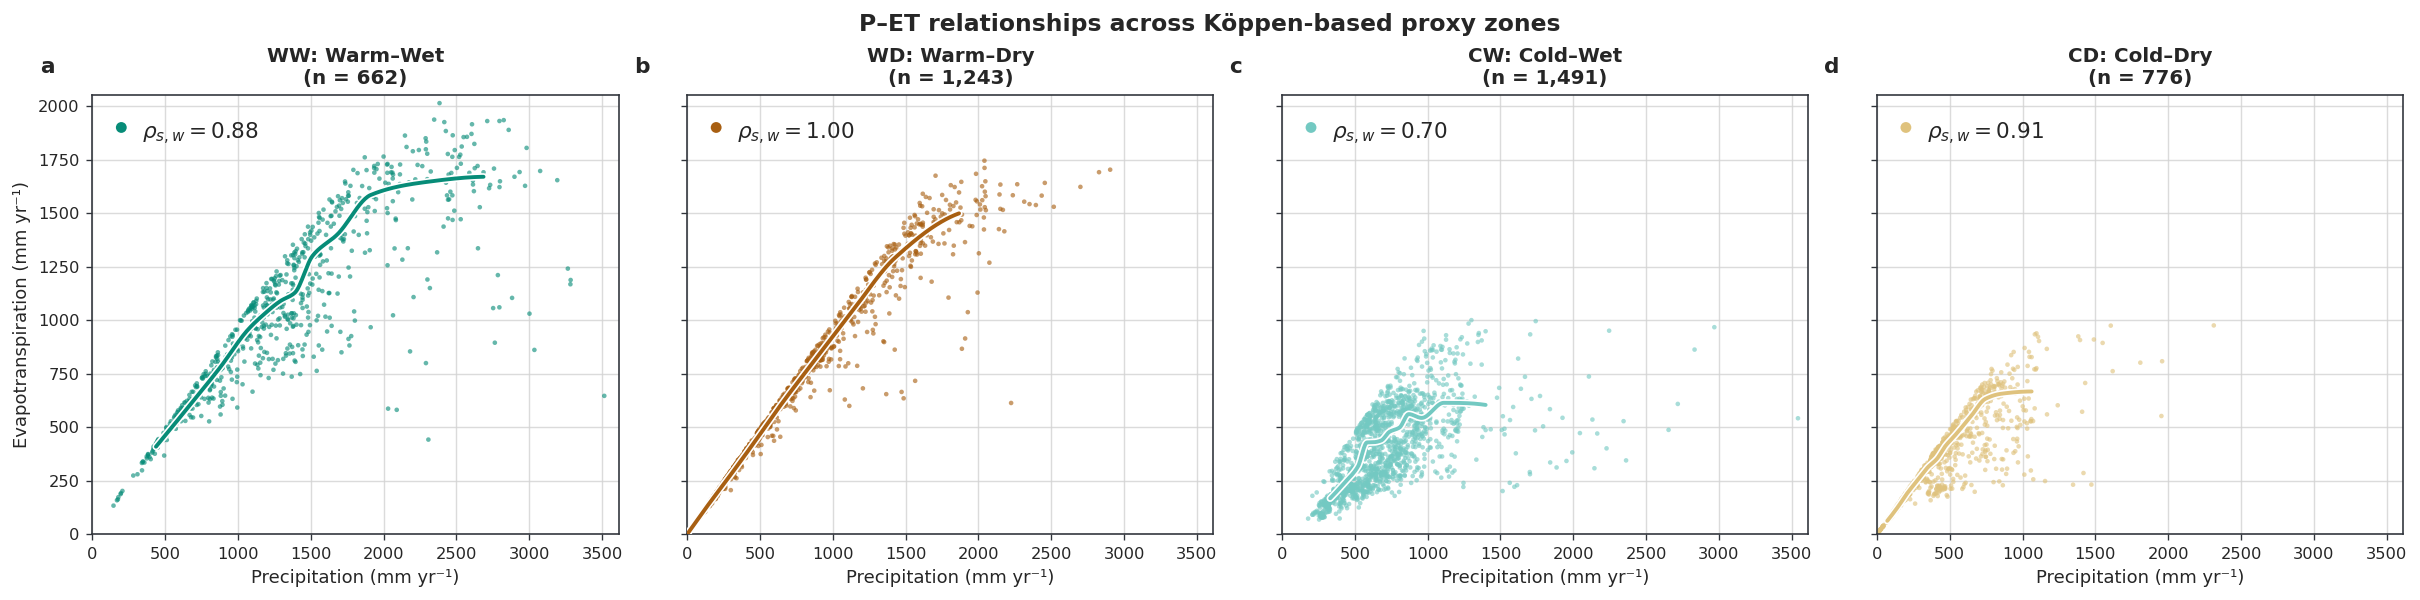

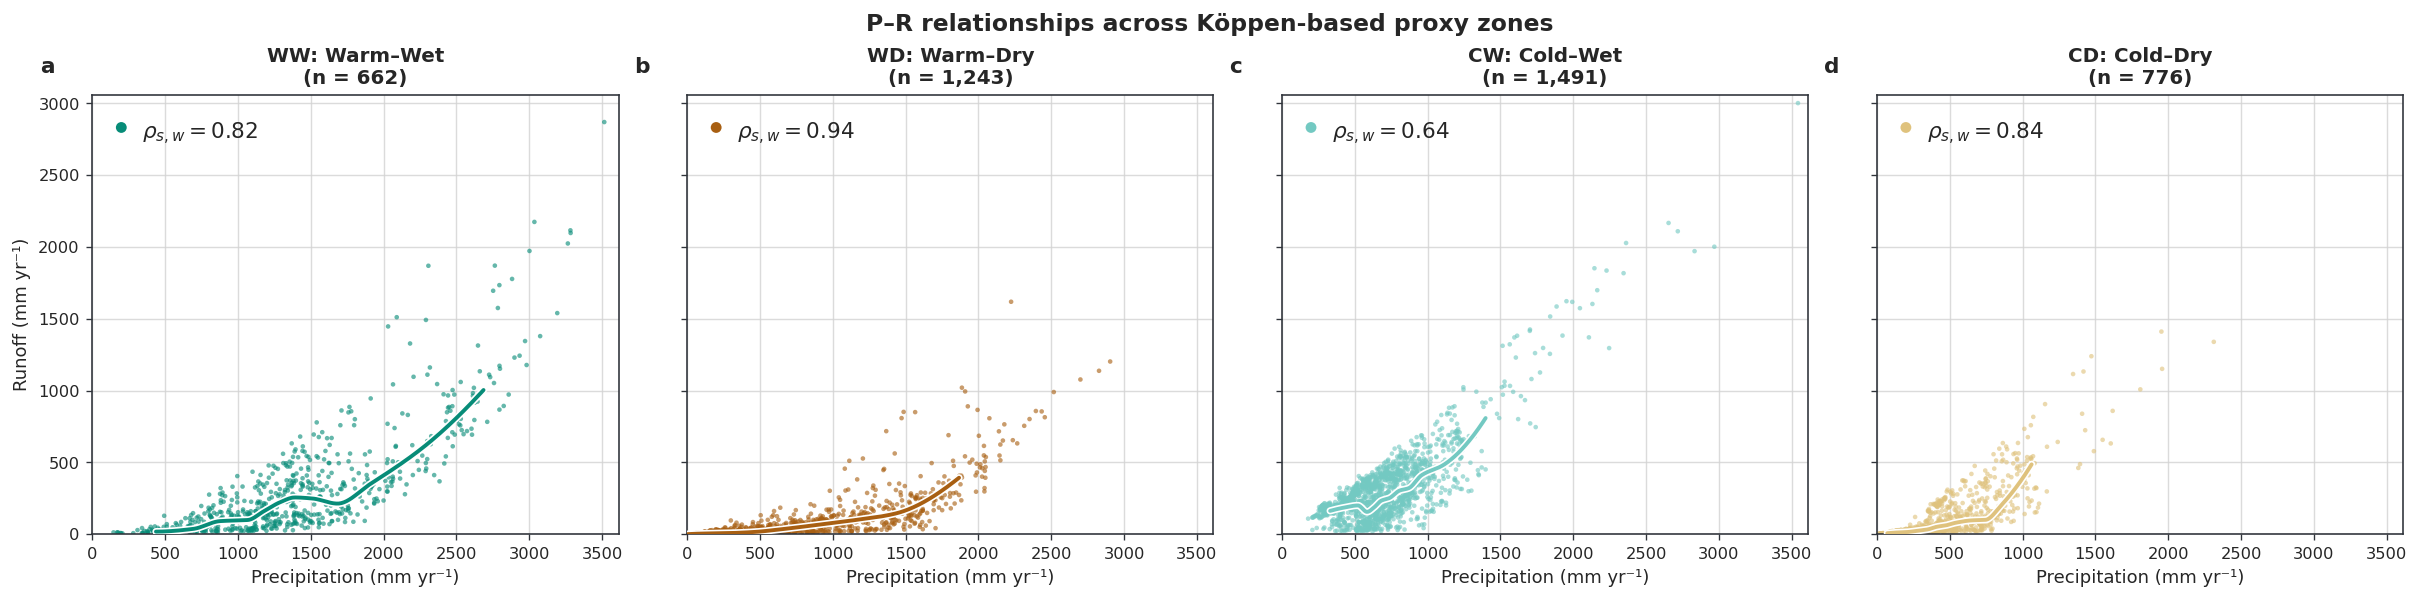

In [6]:
def weighted_binned_curve(frame, x, y, n_bins=N_AREA_BINS):
    edges = np.array([
        weighted_quantile(frame[x], frame["land_area"], q)
        for q in np.linspace(0, 1, n_bins + 1)
    ])
    edges = np.unique(edges)
    labels = pd.cut(frame[x], edges, include_lowest=True, duplicates="drop")
    rows = []
    for _, group in frame.groupby(labels, observed=True):
        rows.append({
            "x": weighted_quantile(group[x], group["land_area"], 0.5),
            "y": weighted_quantile(group[y], group["land_area"], 0.5),
        })
    return pd.DataFrame(rows).drop_duplicates("x").sort_values("x")

def plot_zone_scatter(y, y_label, relationship_label, filename):
    fig, axes = plt.subplots(
        1, 4, figsize=(18.5, 4.5), sharex=True, sharey=True, constrained_layout=True,
    )
    x_limit = float(clim["P"].max()) * 1.02
    y_limit = float(clim[y].max()) * 1.02
    for panel, (ax, zone_name) in enumerate(zip(axes, ZONE_ORDER)):
        group = clim.loc[clim["zone"] == zone_name]
        color = ZONE_COLORS[zone_name]
        ax.scatter(
            group["P"], group[y], s=6.5, color=color, alpha=0.62,
            edgecolors="none", rasterized=True, zorder=2,
        )
        curve = weighted_binned_curve(group, "P", y)
        curve_x = curve["x"].to_numpy()
        curve_y = curve["y"].to_numpy()
        smooth_x = np.linspace(curve_x.min(), curve_x.max(), 250)
        smooth_y = PchipInterpolator(curve_x, curve_y)(smooth_x)
        ax.plot(smooth_x, smooth_y, color="white", linewidth=4.0, zorder=3)
        ax.plot(smooth_x, smooth_y, color=color, linewidth=2.15, zorder=4)
        rho = weighted_spearman(group["P"], group[y], group["land_area"])
        ax.scatter([0.055], [0.925], transform=ax.transAxes, s=36, color=color, edgecolors="none", zorder=5)
        ax.text(0.095, 0.94, rf"$\rho_{{s,w}} = {rho:.2f}$", transform=ax.transAxes, va="top")
        ax.set_title(f"{zone_name}: {ZONE_LABELS[zone_name]}\n(n = {len(group):,})")
        ax.set_xlabel("Precipitation (mm yr⁻¹)")
        ax.set_ylabel(y_label if panel == 0 else "")
        ax.set_xlim(0, x_limit)
        ax.set_ylim(0, y_limit)
        ax.text(-0.10, 1.05, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
        style_axes(ax)
        ax.tick_params(labelbottom=True, labelleft=(panel == 0))
    fig.suptitle(relationship_label, fontsize=13, fontweight="semibold")
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")
    plt.show()

plot_zone_scatter(
    "ET", "Evapotranspiration (mm yr⁻¹)",
    "P–ET relationships across Köppen-based proxy zones",
    "koppen_zone_P_ET_scatter.png",
)
plot_zone_scatter(
    "R", "Runoff (mm yr⁻¹)",
    "P–R relationships across Köppen-based proxy zones",
    "koppen_zone_P_R_scatter.png",
)

## Step 6 — Compare climatological water partitioning among zones

**English.** Compare the ratio of 30-year mean fluxes, ET/P and R/P, using area-weighted medians and interquartile ranges. These two fractions are complementary because the long-term residual is small; they should not be interpreted as two independent responses. This panel asks whether the zone split reveals different water-partition regimes rather than merely different precipitation magnitudes.

**中文。** 用面积加权中位数和四分位范围比较四区的 ET/P 与 R/P。这里使用“30年平均通量之比”，而不是30个年度比值的平均。长期水量残差很小时，ET/P 和 R/P 互补，不应当成两个独立响应。该图用于判断分区是否真的区分了不同的长期水分分配状态，而不只是区分了降水大小。

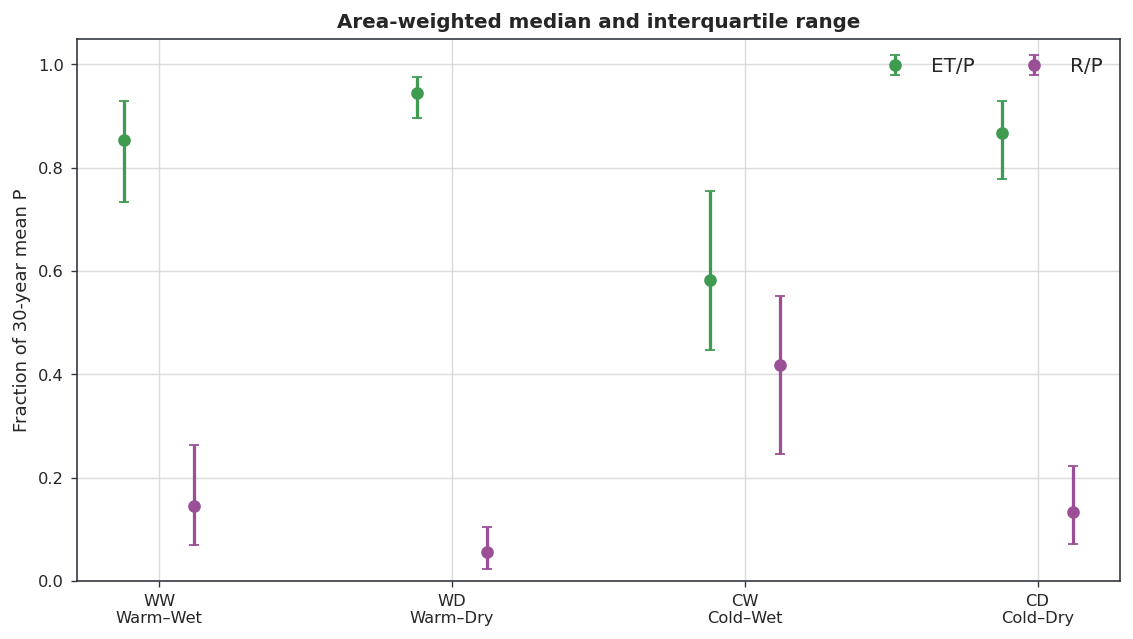

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 4.8), constrained_layout=True)
x_positions = np.arange(len(ZONE_ORDER))
offsets = {"ET_fraction_climatology": -0.12, "R_fraction_climatology": 0.12}
fraction_styles = {
    "ET_fraction_climatology": ("ET/P", "#3E9B50"),
    "R_fraction_climatology": ("R/P", "#9B4F96"),
}
for variable, (label, color) in fraction_styles.items():
    medians = zone_summary[f"{variable}_median"].to_numpy()
    lower = medians - zone_summary[f"{variable}_q25"].to_numpy()
    upper = zone_summary[f"{variable}_q75"].to_numpy() - medians
    ax.errorbar(
        x_positions + offsets[variable], medians, yerr=np.vstack([lower, upper]),
        fmt="o", markersize=6, color=color, ecolor=color, elinewidth=1.8,
        capsize=3, label=label, zorder=3,
    )
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{zone}\n{ZONE_LABELS[zone]}" for zone in ZONE_ORDER])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fraction of 30-year mean P")
ax.set_title("Area-weighted median and interquartile range")
ax.legend(frameon=False, ncol=2)
style_axes(ax)
fig.savefig(FIGURE_DIR / "koppen_zone_partition_fractions.png", bbox_inches="tight")
plt.show()

## Step 7 — Purity sensitivity check

**English.** Recalculate the main correlations and fraction medians using only cells with at least 60% dominant-zone purity. The full sample remains the primary result; the core-cell comparison asks whether mixed boundary cells qualitatively change the conclusions. A large change would mean that coarse-grid class assignment needs more careful treatment.

**中文。** 仅用主类纯度至少60%的“核心网格”重新计算主要相关和分配比中位数。全部样本仍是主结果；这个对照只检查气候边界的混合网格是否改变定性结论。如果结果变化很大，说明粗网格分类还需要更谨慎的处理。

In [8]:
sensitivity_rows = []
for zone_name in ZONE_ORDER:
    for sample_name, mask in [
        ("all_assigned", clim["zone"] == zone_name),
        ("core_purity_ge_0p60", (clim["zone"] == zone_name) & clim["core_zone_cell"]),
    ]:
        group = clim.loc[mask]
        weights = group["land_area"]
        sensitivity_rows.append({
            "zone": zone_name, "sample": sample_name, "grid_cells": len(group),
            "weighted_rank_r_P_ET": weighted_spearman(group["P"], group["ET"], weights),
            "weighted_rank_r_P_R": weighted_spearman(group["P"], group["R"], weights),
            "median_ET_fraction": weighted_quantile(group["ET_fraction_climatology"], weights),
            "median_R_fraction": weighted_quantile(group["R_fraction_climatology"], weights),
        })
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.set_index(["zone", "sample"]).round(3))

grid_cells  weighted_rank_r_P_ET  \
zone sample                                                  
WW   all_assigned                662                 0.883   
     core_purity_ge_0p60         604                 0.892   
WD   all_assigned               1243                 0.996   
     core_purity_ge_0p60        1176                 0.997   
CW   all_assigned               1491                 0.699   
     core_purity_ge_0p60        1428                 0.697   
CD   all_assigned                776                 0.908   
     core_purity_ge_0p60         699                 0.912   

                          weighted_rank_r_P_R  median_ET_fraction  \
zone sample                                                         
WW   all_assigned                       0.820               0.853   
     core_purity_ge_0p60                0.810               0.851   
WD   all_assigned                       0.945               0.945   
     core_purity_ge_0p60                0.949               0.948   
CW   all_assigned                       0.644               0.583   
     core_purity_ge_0p60                0.633               0.582   
CD   all_assigned                       0.838               0.868   
     core_purity_ge_0p60                0.844               0.872   

                          median_R_fraction  
zone sample                                  
WW   all_assigned                     0.145  
     core_purity_ge_0p60              0.148  
WD   all_assigned                     0.056  
     core_purity_ge_0p60              0.053  
CW   all_assigned                     0.418  
     core_purity_ge_0p60              0.419  
CD   all_assigned                     0.133  
     core_purity_ge_0p60              0.131

## Step 8 — Save analysis-ready products

**English.** Save one row per non-ice land grid cell with the Köppen audit fields, the zone summary and sensitivity tables, and a gridded NetCDF. These products can later be joined to additional ESM predictors or used for tree analysis without repeating the categorical aggregation.

**中文。** 保存每个非冰川陆地网格一行的 Köppen 增强数据表、四区汇总表、纯度敏感性表以及网格化 NetCDF。后续可直接加入其他 ESM 驱动变量或进入 tree，无需重复做类别聚合。

In [9]:
ZONE_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zone_climatology_1985_2014.parquet"
ZONE_SUMMARY = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zone_summary_1985_2014.csv"
ZONE_SENSITIVITY = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zone_purity_sensitivity_1985_2014.csv"
ZONE_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_koppen_zones_1985_2014.nc"

zone_grid = xr.Dataset(
    {
        "zone_code": (("lat", "lon"), np.where(analysis_mask, dominant_zone_code, 0).astype("int8")),
        "zone_purity": (("lat", "lon"), np.where(analysis_mask, zone_purity, np.nan).astype("float32")),
        "kg_grouped_coverage": (("lat", "lon"), np.where(analysis_mask, kg_grouped_coverage, np.nan).astype("float32")),
        "kg_mean_confidence": (("lat", "lon"), np.where(analysis_mask, kg_mean_confidence, np.nan).astype("float32")),
        "dominant_koppen_code": (("lat", "lon"), np.where(analysis_mask, dominant_koppen_code, 0).astype("int16")),
        "analysis_cell": spatial["analysis_cell"].astype("int8"),
    },
    coords={"lat": spatial.lat, "lon": spatial.lon},
)
zone_grid["zone_code"].attrs.update({
    "long_name": "dominant Koppen-based four-zone proxy",
    "flag_values": np.array([0, 1, 2, 3, 4], dtype="int8"),
    "flag_meanings": "unassigned WW WD CW CD",
})
zone_grid["zone_purity"].attrs.update({"units": "1", "valid_min": 0.0, "valid_max": 1.0})
zone_grid["kg_grouped_coverage"].attrs.update({"units": "1", "valid_min": 0.0, "valid_max": 1.0})
zone_grid["kg_mean_confidence"].attrs["units"] = "percent"
zone_grid.attrs.update({
    "title": "Koppen-based proxy zones on MPI-ESM1-2-LR non-ice land grid",
    "analysis_period": f"{START_YEAR}-{END_YEAR}",
    "aggregation": "cos(latitude)-weighted dominant group of 0.1-degree pixel centers",
    "warning": "Proxy grouping; not identical to the reference paper climate-region definition",
})

if WRITE_OUTPUTS:
    table_to_save = clim.copy()
    table_to_save["zone"] = table_to_save["zone"].astype(str)
    table_to_save.to_parquet(ZONE_TABLE, index=False)
    zone_summary.to_csv(ZONE_SUMMARY)
    sensitivity.to_csv(ZONE_SENSITIVITY, index=False)
    encoding = {name: {"zlib": True, "complevel": 4} for name in zone_grid.data_vars}
    zone_grid.to_netcdf(ZONE_NETCDF, encoding=encoding)

manifest = pd.DataFrame([
    {"product": "Grid-cell Köppen table", "path": ZONE_TABLE},
    {"product": "Zone summary", "path": ZONE_SUMMARY},
    {"product": "Purity sensitivity", "path": ZONE_SENSITIVITY},
    {"product": "Gridded Köppen proxy", "path": ZONE_NETCDF},
    {"product": "Figure directory", "path": FIGURE_DIR},
])
manifest["exists"] = manifest["path"].map(Path.exists)
manifest["size_MB"] = manifest["path"].map(
    lambda path: np.nan if path.is_dir() else path.stat().st_size / 1e6
)
display(manifest)

,product,path,exists,size_MB
0,Grid-cell Köppen table,/Users/mimi/Documents/Code/Github/GSA-work/exp...,True,0.392955
1,Zone summary,/Users/mimi/Documents/Code/Github/GSA-work/exp...,True,0.002322
2,Purity sensitivity,/Users/mimi/Documents/Code/Github/GSA-work/exp...,True,0.000901
3,Gridded Köppen proxy,/Users/mimi/Documents/Code/Github/GSA-work/exp...,True,0.059812
4,Figure directory,/Users/mimi/Documents/Code/Github/GSA-work/exp...,True,NaN


## Step 9 — Result interpretation and completion checks

**English.** Interpret a useful zone split as a combination of (1) visibly different point clouds or curves, (2) materially different ET/P and R/P summaries, and (3) conclusions that remain similar after the purity sensitivity check. Differences are descriptive, not causal: Köppen classes encode temperature and precipitation regimes but do not expose the actual ESM mechanisms. Temperature, radiation, soil moisture, snow, and vegetation variables are still needed before a mechanistic tree analysis.

**中文。** 如果这个分区真的有用，应同时看到：（1）四区的散点云或平滑曲线明显不同；（2）ET/P 与 R/P 汇总值存在有意义的差异；（3）只保留纯度至少60%的核心网格后，主要结论没有翻转。这些差异仍然只是描述性的，不是因果机制证据。Köppen 分类浓缩了温度和降水状态，但没有直接提供 ESM 中的辐射、土壤水分、积雪和植被过程；在做机制性 tree 之前，这些驱动变量仍需补充。

In [10]:
reopened_table = pd.read_parquet(ZONE_TABLE)
reopened_grid = xr.open_dataset(ZONE_NETCDF)
completion = pd.Series({
    "table_rows": len(reopened_table),
    "unique_grid_ids": reopened_table["grid_id"].nunique(),
    "assigned_zone_rows": reopened_table["zone"].isin(ZONE_ORDER).sum(),
    "gridded_analysis_cells": int(reopened_grid["analysis_cell"].sum()),
    "gridded_assigned_cells": int((reopened_grid["zone_code"] > 0).sum()),
    "saved_png_figures": len(list(FIGURE_DIR.glob("*.png"))),
})
display(completion.to_frame("value"))
assert completion["table_rows"] == completion["unique_grid_ids"] == len(clim)
assert completion["assigned_zone_rows"] == len(clim)
assert completion["gridded_analysis_cells"] == completion["gridded_assigned_cells"] == len(clim)
assert completion["saved_png_figures"] == 5

reopened_grid.close()
kg_ds.close()
spatial.close()
print("Step 5 completed successfully.")

,value
table_rows,4172
unique_grid_ids,4172
assigned_zone_rows,4172
gridded_analysis_cells,4172
gridded_assigned_cells,4172
saved_png_figures,5


Step 5 completed successfully.
